# Лаб 3

1. пишем класс модели SVM
2. в классе должны быть методы:
```
def __init__(...):
#some code
def predict(...):
#some code
def fit(...):
#some code
```

3. берем датасет (решаем только задачу классификации).
Датасет тяжелый, около 9 гигов.
```
import moabb.datasets

m_dataset = moabb.datasets.bi2013a(
    NonAdaptive=True,
    Adaptive=True,
    Training=True,
    Online=True,
)

m_dataset.download()
```

4. предобрабатываем датасет
5. обучаем модель
6. выводим метрики качества (ошибки, точность предсказаний, etc.)

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Мои 3 любимых класса

In [ ]:
import numpy as np
from dataclasses import dataclass
import torch

@dataclass
class SeparateData:
  X_train: torch.Tensor
  y_train: torch.Tensor
  X_val: torch.Tensor
  y_val: torch.Tensor
  X_test: torch.Tensor
  y_test: torch.Tensor

class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X: torch.Tensor) -> None:
        X = X.clone().detach().to(torch.float32)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        self.mean = torch.mean(X, dim=0)
        self.std = torch.std(X, dim=0)

        self.std = torch.where(self.std == 0, torch.tensor(1.0), self.std)

    def transform(self, X: torch.Tensor) -> torch.Tensor:
        if self.mean is None or self.std is None:
            return X

        X = X.clone().detach().to(torch.float32)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        return (X - self.mean) / self.std

    def fit_transform(self, X: torch.Tensor) -> torch.Tensor:
        self.fit(X)
        return self.transform(X)

class DataSeparator:
   def __init__(self, val_size: float = 0.2, test_size: float = 0.1,
                 shuffle: bool = True, seed: int = 42, device: torch.device = device):
        self.val_size = val_size
        self.test_size = test_size
        self.shuffle = shuffle
        self.seed = seed
        self.device = device

   def separate(self, X: torch.tensor, y: torch.tensor) -> SeparateData:
    n_samples = X.shape[0]
    indices = torch.arange(n_samples)

    if self.shuffle:
         torch.manual_seed(self.seed)
         indices = torch.randperm(n_samples)

    test_samples = int(n_samples * self.test_size)
    val_samples = int(n_samples * self.val_size)
    train_samples = n_samples - test_samples - val_samples

    train_indices = indices[:train_samples]
    val_indices = indices[train_samples: train_samples + val_samples]
    test_indices = indices[train_samples + val_samples:]

    X_train = X[train_indices].to(self.device)
    y_train = y[train_indices].to(self.device)
    X_val   = X[val_indices].to(self.device)
    y_val   = y[val_indices].to(self.device)
    X_test  = X[test_indices].to(self.device)
    y_test  = y[test_indices].to(self.device)

    return SeparateData(X_train, y_train, X_val, y_val, X_test, y_test)

## Пишем класс модели SVM

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

class SVM:
  def __init__(self, C: float = 1.0, learning_rate: float = 0.1, fit_intercept: bool = True, epochs: int = 10, batch_size: int = 50, device: torch.device = device):
    self.C = C
    self.learning_rate = learning_rate
    self.epochs = epochs
    self.batch_size = batch_size
    self.device = device
    self.weights = None
    self.fit_intercept = fit_intercept
    self.bias = 0.0 if fit_intercept else None
    self.train_loss_history = []
    self.train_accuracy_history = []
    self.val_loss_history = []
    self.val_accuracy_history = []
    self.is_fitted = False

  def _learn(self, X_train: torch.Tensor, y_train: torch.Tensor, X_val: torch.Tensor, y_val: torch.Tensor):
    n_samples, n_features = X_train.shape
    params = [p for p in [self.weights, self.bias] if p is not None]
    optimizer = torch.optim.Adam(params, lr=self.learning_rate)

    for i in range (1, self.epochs + 1):
      sum_loss = 0.0
      sum_correct = 0
      n_seen = 0
      for start in range(0, n_samples, self.batch_size):
        end = start + self.batch_size
        X_batch = X_train[start:end].to(self.device)
        y_batch = y_train[start:end].to(self.device)

        scores = X_batch @ self.weights + (self.bias if self.fit_intercept else 0.0)

        hinge = torch.clamp(1 - y_batch * scores, min=0)
        loss = 0.5 * torch.sum(self.weights ** 2) + self.C * hinge.mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = torch.sign(scores)
        sum_correct += (preds == y_batch).sum().item()
        n_seen += y_batch.size(0)
        sum_loss += loss.item() * y_batch.size(0)

      epoch_loss = sum_loss / n_seen
      epoch_acc = sum_correct / n_seen

      self.train_loss_history.append(epoch_loss)
      self.train_accuracy_history.append(epoch_acc)

      with torch.no_grad():
        val_scores = X_val @ self.weights + (self.bias if self.fit_intercept else 0.0)
        val_hinge = torch.clamp(1 - y_val * val_scores, min=0)
        val_loss = 0.5 * torch.sum(self.weights ** 2).item() + self.C * val_hinge.mean().item()
        val_preds = torch.sign(val_scores)
        val_acc = (val_preds == y_val).float().mean().item()
        self.val_loss_history.append(val_loss)
        self.val_accuracy_history.append(val_acc)

      print(f"Epoch {i}/{self.epochs} — Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")



  def fit(self, X_train: torch.Tensor, y_train: torch.Tensor, X_val: torch.Tensor, y_val: torch.Tensor):
    n_samples, n_features = X_train.shape
    self.weights = torch.zeros(n_features, device=self.device, requires_grad=True)

    if self.fit_intercept:
      self.bias = torch.tensor(0.0, device=self.device, requires_grad=True)

    self._learn(X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val)

    self.is_fitted = True

  def predict(self, X_test: torch.Tensor) -> torch.Tensor:
    if not(self.is_fitted):
      raise RuntimeError("Model is not fitted yet!")

    s = X_test @ self.weights + (self.bias if self.fit_intercept else 0.0)
    preds = torch.sign(s)

    return preds

  def evaluate(self, y_pred: torch.Tensor, y_test: torch.Tensor):
    y_pred = y_pred.detach().cpu().numpy()
    y_test = y_test.detach().cpu().numpy()

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f}")

  def plot_metrics(self):
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    # Loss
    axes[0].plot(self.train_loss_history, label='Train', linewidth=2)
    axes[0].plot(self.val_loss_history, label='Validation', linewidth=2)
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(self.train_accuracy_history, label='Train', linewidth=2)
    axes[1].plot(self.val_accuracy_history, label='Validation', linewidth=2)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"SVM model training and validation metrics", fontsize=16)
    plt.tight_layout()
    plt.show()

## Работаем с основным датасетом

In [ ]:
!pip install moabb -q

In [ ]:
import moabb.datasets

m_dataset = moabb.datasets.bi2013a(
    NonAdaptive=True,
    Adaptive=True,
    Training=True,
    Online=True,
)

m_dataset.download()

In [ ]:
subjects = m_dataset.subject_list
print("Субъекты:", subjects)
all_data = m_dataset.get_data(subjects=subjects)

Субъекты: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


In [ ]:
import moabb.datasets
import mne
import numpy as np
import gc

X_all, y_all = [], []

for session_name, session_runs in all_data.items():
    print(f"Processing {session_name}")
    for run_name, run_data in session_runs.items():
        print(f"processing {run_name}\n")
        for subrun_key, raw in run_data.items():
            events, event_ids = mne.events_from_annotations(raw)

            psd_obj = raw.compute_psd(method='multitaper', fmin=8, fmax=30, tmin=0, tmax=1, verbose=False)
            psd, freqs = psd_obj.get_data(return_freqs=True)

            for onset, _, code_int in events:
                code_str = [k for k,v in event_ids.items() if v==code_int][0]
                feature = psd.flatten()
                X_all.append(feature)
                y_all.append(1 if code_str=="Target" else -1)

X = torch.tensor(X_all, dtype=torch.float32)
y = torch.tensor(y_all, dtype=torch.float32)
print("Размер данных:", X.shape)
print("Классы:", np.unique(y))

Processing 1
processing 7

Used Annotations descriptions: ['NonTarget', 'Target']
Used Annotations descriptions: ['NonTarget', 'Target']
Used Annotations descriptions: ['NonTarget', 'Target']
Used Annotations descriptions: ['NonTarget', 'Target']
processing 6

Used Annotations descriptions: ['NonTarget', 'Target']
Used Annotations descriptions: ['NonTarget', 'Target']
Used Annotations descriptions: ['NonTarget', 'Target']
Used Annotations descriptions: ['NonTarget', 'Target']
processing 0

Used Annotations descriptions: ['NonTarget', 'Target']
Used Annotations descriptions: ['NonTarget', 'Target']
Used Annotations descriptions: ['NonTarget', 'Target']
Used Annotations descriptions: ['NonTarget', 'Target']
processing 1

Used Annotations descriptions: ['NonTarget', 'Target']
Used Annotations descriptions: ['NonTarget', 'Target']
Used Annotations descriptions: ['NonTarget', 'Target']
Used Annotations descriptions: ['NonTarget', 'Target']
processing 5

Used Annotations descriptions: ['NonT

/tmp/ipython-input-507208542.py:24: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.tensor(X_all, dtype=torch.float32)


In [ ]:
separator = DataSeparator(test_size=0.15, val_size=0.15, shuffle=True, seed=42)
data_splits = separator.separate(X, y)
scaler = StandardScaler()
scaler.fit(data_splits.X_train)

data_splits.X_train = scaler.transform(data_splits.X_train)
data_splits.X_val = scaler.transform(data_splits.X_val)
data_splits.X_test = scaler.transform(data_splits.X_test)

Разделили датасет!


Начали обучать
Epoch 1/100 — Train Loss: 0.9564, Train Acc: 0.7682 | Val Loss: 0.9042, Val Acc: 0.8279
Epoch 2/100 — Train Loss: 0.8598, Train Acc: 0.8164 | Val Loss: 0.8054, Val Acc: 0.8287
Epoch 3/100 — Train Loss: 0.7627, Train Acc: 0.8198 | Val Loss: 0.7085, Val Acc: 0.8309
Epoch 4/100 — Train Loss: 0.6658, Train Acc: 0.8224 | Val Loss: 0.6108, Val Acc: 0.8321
Epoch 5/100 — Train Loss: 0.5688, Train Acc: 0.8231 | Val Loss: 0.5126, Val Acc: 0.8321
Epoch 6/100 — Train Loss: 0.4716, Train Acc: 0.8259 | Val Loss: 0.4152, Val Acc: 0.8335
Epoch 7/100 — Train Loss: 0.3767, Train Acc: 0.8296 | Val Loss: 0.3297, Val Acc: 0.8358
Epoch 8/100 — Train Loss: 0.3382, Train Acc: 0.8325 | Val Loss: 0.3301, Val Acc: 0.8358
Epoch 9/100 — Train Loss: 0.3388, Train Acc: 0.8324 | Val Loss: 0.3306, Val Acc: 0.8358
Epoch 10/100 — Train Loss: 0.3375, Train Acc: 0.8324 | Val Loss: 0.3298, Val Acc: 0.8358
Epoch 11/100 — Train Loss: 0.3386, Train Acc: 0.8324 | Val Loss: 0.3310, Val Acc: 0.8358
Epoch 12/100 — 

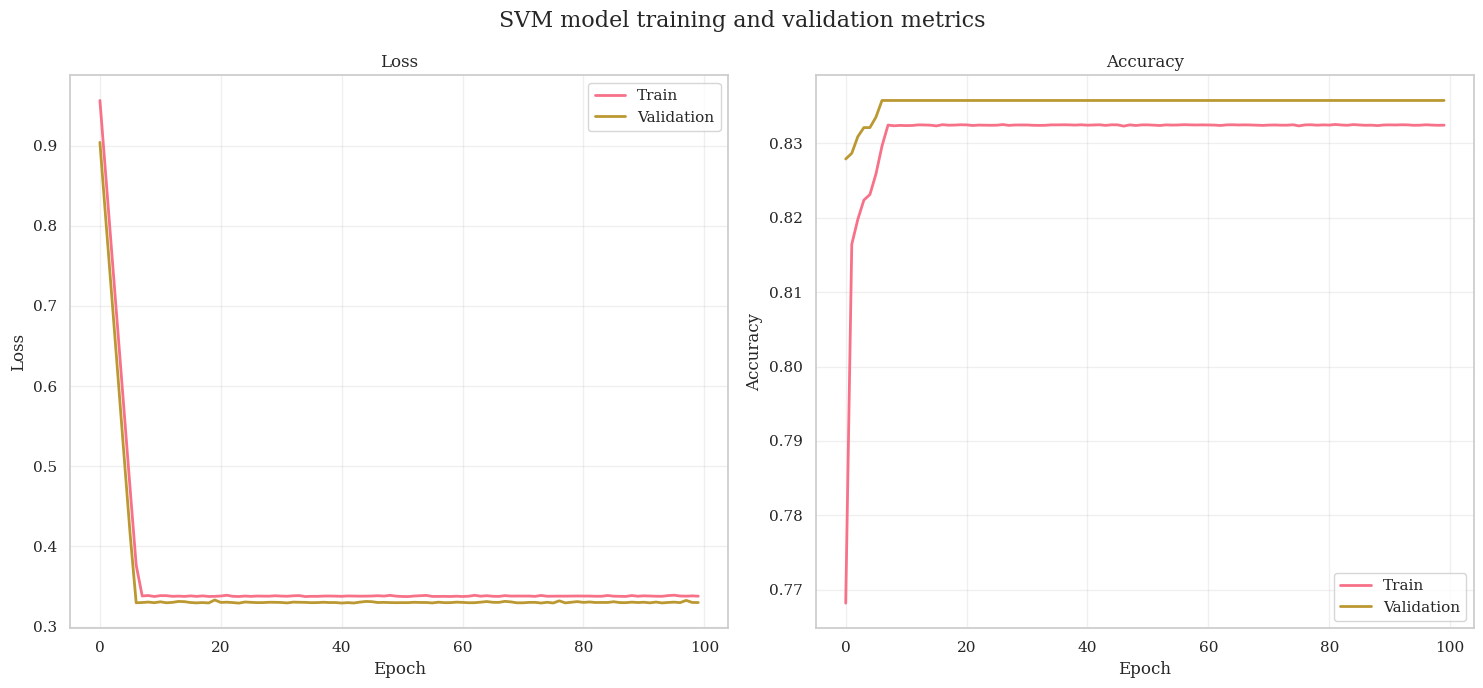

In [ ]:
model = SVM(learning_rate=0.001, fit_intercept=True, epochs=100, batch_size=500, device=device)
model.fit(data_splits.X_train, data_splits.y_train, data_splits.X_val, data_splits.y_val)

predictions = model.predict(data_splits.X_test)

model.evaluate(predictions, data_splits.y_test)
model.plot_metrics()